Análise de Vendas - Loja de Chocolates




## 🎯 Objetivo

Analisar o desempenho de vendas ao longo do ano, identificando sazonalidade,
produtos mais lucrativos e oportunidades de negócio.

## 📌 Contexto

Este dataset simula uma empresa do setor de chocolates com faturamento anual,
incluindo efeitos sazonais como Páscoa e Natal.

## 📊 Análise Geral

In [2]:
import pandas as pd
df = pd.read_csv('../data/vendas.csv')
df.head()

,data,produto,categoria,preco,custo,quantidade,faturamento,custo_total,lucro
0,2024-01-01,Trufa,Premium,8,3,71,568,213,355
1,2024-01-01,Barra 100g,Tradicional,12,5,34,408,170,238
2,2024-01-01,Caixa de Bombom,Presente,35,18,91,3185,1638,1547
3,2024-01-01,Ovo de Páscoa,Sazonal,80,40,80,6400,3200,3200
4,2024-01-01,Chocolate Amargo,Premium,15,7,40,600,280,320


In [10]:
desc = df.describe()

# função formato brasileiro
def formato_brl(x):
    return f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

# aplicar formatação só nas colunas de dinheiro
colunas_dinheiro = ['preco', 'custo', 'faturamento', 'custo_total', 'lucro']

desc_formatado = desc.copy()

for col in colunas_dinheiro:
    desc_formatado[col] = desc[col].apply(formato_brl)

# quantidade fica normal (sem R$)
desc_formatado['quantidade'] = desc['quantidade'].round(0)

desc_formatado

,preco,custo,quantidade,faturamento,custo_total,lucro,mes
count,"R$ 1.830,00","R$ 1.830,00",1830.0,"R$ 1.830,00","R$ 1.830,00","R$ 1.830,00",1830.000000
mean,"R$ 30,00","R$ 14,60",73.0,"R$ 2.154,96","R$ 1.047,98","R$ 1.106,98",6.513661
std,"R$ 26,68","R$ 13,72",47.0,"R$ 2.633,52","R$ 1.336,05","R$ 1.299,42",3.452177
min,"R$ 8,00","R$ 3,00",20.0,"R$ 160,00","R$ 60,00","R$ 100,00",1.000000
25%,"R$ 12,00","R$ 5,00",43.0,"R$ 632,00","R$ 252,00","R$ 365,00",4.000000
50%,"R$ 15,00","R$ 7,00",65.0,"R$ 1.126,50","R$ 504,00","R$ 624,00",7.000000
75%,"R$ 35,00","R$ 18,00",86.0,"R$ 2.835,00","R$ 1.400,00","R$ 1.394,00",10.000000
max,"R$ 80,00","R$ 40,00",297.0,"R$ 22.560,00","R$ 11.280,00","R$ 11.280,00",12.000000


## 💰 Indicadores Gerais

In [4]:
faturamento_total = df['faturamento'].sum()
lucro_total = df['lucro'].sum()

print(f'Faturamento total: R$ {faturamento_total:,.2f}')
print(f'Lucro total: R$ {lucro_total:,.2f}')

Faturamento total: R$ 3,943,573.00
Lucro total: R$ 2,025,770.00


## 📊 Faturamento por Mês

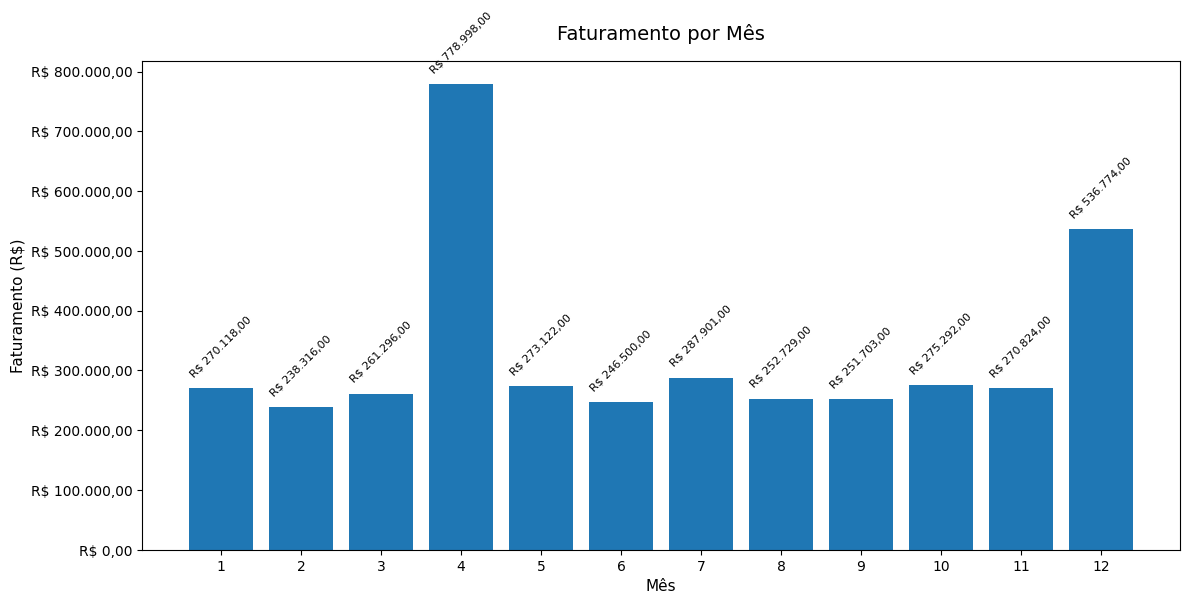

In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# criar coluna de mês
df['mes'] = pd.to_datetime(df['data']).dt.month

# agrupar
faturamento_mes = df.groupby('mes')['faturamento'].sum()

# função para formato brasileiro
def formato_brl(x, pos):
    return f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

# gráfico
plt.figure(figsize=(12,6))

bars = plt.bar(faturamento_mes.index, faturamento_mes.values)

# título e labels
plt.title('Faturamento por Mês', fontsize=14, pad=15)
plt.xlabel('Mês', fontsize=11)
plt.ylabel('Faturamento (R$)', fontsize=11)

# aplicar formatação brasileira no eixo Y
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(formato_brl))

# melhorar espaçamento
plt.xticks(faturamento_mes.index)
plt.tight_layout()

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + (max(faturamento_mes.values) * 0.02),  # espaçamento proporcional
        formato_brl(y, None),
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=45  # inclina pra não sobrepor
    )

plt.show()

### 💡 Insight

Observa-se um aumento significativo no faturamento nos meses 4 e 12, indicando forte influência de datas sazonais como Páscoa e Natal.

Esses períodos representam oportunidades estratégicas para maximização de receita.

## 🏆 Top Produtos por Faturamento

In [12]:
top_produtos = df.groupby('produto')['faturamento'].sum().sort_values(ascending=False)

# função formato brasileiro
def formato_brl(x):
    return f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

# aplicar formatação
top_produtos_formatado = top_produtos.apply(formato_brl)

top_produtos_formatado

produto
Ovo de Páscoa       R$ 2.055.200,00
Caixa de Bombom       R$ 941.780,00
Chocolate Amargo      R$ 407.685,00
Barra 100g            R$ 324.372,00
Trufa                 R$ 214.536,00
Name: faturamento, dtype: str

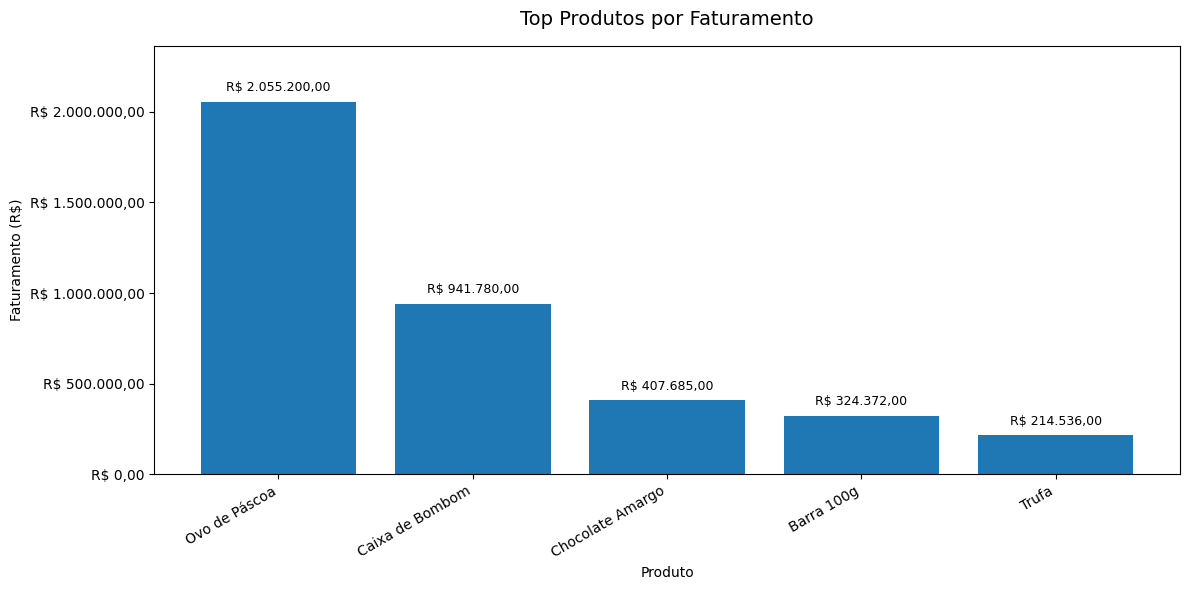

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# função formato brasileiro
def formato_brl(x, pos):
    return f'R$ {x:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

plt.figure(figsize=(12,6))

bars = plt.bar(top_produtos.index, top_produtos.values)

plt.title('Top Produtos por Faturamento', fontsize=14, pad=15)
plt.xlabel('Produto')
plt.ylabel('Faturamento (R$)')

# eixo Y formatado
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(formato_brl))

# rotacionar nomes
plt.xticks(rotation=30, ha='right')

# espaçamento automático
plt.tight_layout()

# valores nas barras
for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y + (max(top_produtos.values) * 0.02),
        formato_brl(y, None),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.ylim(0, max(top_produtos.values) * 1.15)

plt.show()